In [80]:
# Important Imports
import dynamiqs as dq
import jax.numpy as jnp
from pathlib import Path
import json
import matplotlib.pyplot as plt


In [81]:
###############  Simulqting Single Cavity #################
# Define the system parameters
N = 45             # Truncation Dimension
Delta = 1.0        # Detuning (in MHz)
kappa = 1.0        # Cavity decay rate (in MHz)
Drive_amp = 1.0    # Drive amplitude (in MHz)

# Defining the System Operators, Hamiltonian, Dissipators and Observables
a = dq.destroy(N)
H = 2*jnp.pi*Delta*a.dag() @ a 
H_drive = 2*1j*jnp.pi*Drive_amp*(a.dag() - a)
obvs = [a.dag()@a, a, a.dag()]
Dissipators = [jnp.sqrt(kappa)*a]

# Defining the Scope
rho0 = dq.coherent_dm(N,0.0)
T = 20.0     # Total time in us
td = 1000    # Number of time steps 
times = jnp.linspace(0,T,td)
Drive = True

method = dq.method.Tsit5(rtol=1e-6, atol=1e-9)
if Drive :
    H = H + H_drive

In [82]:
# Running the Simulation
result = dq.mesolve(H, Dissipators, rho0, tsave=times, exp_ops=obvs, method=method)
print(result)

|██████████| 100.0% ◆ elapsed 936.32ms ◆ remaining 0.00ms  

==== MESolveResult ====
Method  : Tsit5
Infos   : 2549 steps (2543 accepted, 6 rejected)
States  : QArray complex64 (1000, 45, 45) | 15.4 Mb
Expects : Array complex64 (3, 1000) | 23.4 Kb


Theoretical ss amplitude : 0.9937072751678742 and simulated ss amplitude : 0.993615448474884
Theoretical phase : -85.45013427734375 and simulated phase : 85.45011138916016


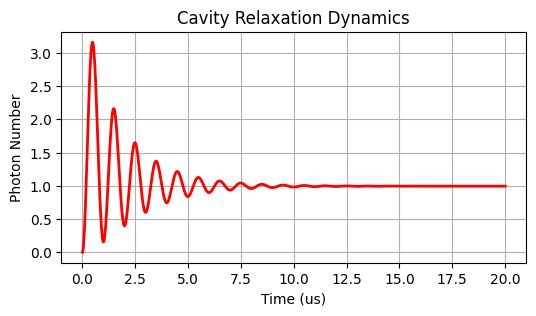

In [89]:
# Analyzing the Results
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(times, result.expects[0].real, linewidth=2, color = "r")
ax.set_xlabel("Time (us)")
ax.set_ylabel("Photon Number")
ax.set_title("Cavity Relaxation Dynamics")
ax.grid()

ss_amp_th = 2*jnp.pi*Drive_amp/ (2*jnp.pi*1j*Delta + kappa/2)
ss_amp_sim = abs(result.expects[0][-1])

print(f"Theoretical ss amplitude : {abs(ss_amp_th)**2} and simulated ss amplitude : {ss_amp_sim}")
A = result.expects[2]
print(f"Theoretical phase : {jnp.angle(ss_amp_th, deg=True)} and simulated phase : {jnp.angle(A[-1], deg=True)}")